## Step 1: Import Libraries and Load Processed Data

In previous sections, we cleaned and standardized the credit-default dataset, established the logistic likelihood framework with MLE, compared frequentist and Bayesian uncertainty perspectives, and evaluated predictive performance using train/test and resampling-based diagnostics.

Building on that sequence, this section introduces regularization and shrinkage for logistic regression. Using the same full feature set, we compare an approximately unpenalized baseline against Ridge (L2), Lasso (L1), and Elastic Net (L1 + L2 mix) models tuned by cross-validation. **Standardization is fit on the training split only** before evaluation on the holdout test set.

## Step 2: Train/Test Split and Standardization

We use a stratified 80/20 split (`random_state=42`) so the class balance matches earlier prediction notebooks. **StandardScaler is fit only on the training features** (`fit_transform` on train, `transform` on test) to avoid leaking test-set marginal information into scaling. Regularization penalties are scale-sensitive, so all models use these scaled train/test matrices.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import average_precision_score, precision_recall_curve

# Load processed data
df = pd.read_csv("../data/processed/cleaned_default_data.csv")
df.columns = df.columns.str.strip()

target = "default payment next month"
feature_cols = [col for col in df.columns if col != target]

X = df[feature_cols].values
y = df[target].values

# Stratified holdout, then standardize: fit scaler on TRAIN only (no test leakage)
X_train_raw, X_test_raw, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df, test_size=0.2, stratify=y, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
X_train_df = pd.DataFrame(X_train, columns=feature_cols)
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

## Step 3: Baseline MLE Logistic (training sample)

For comparability with the holdout below, the **statsmodels** logit is fit on the **training fold only** using **train-scaled** features. (This differs from a full-sample MLE in `likelihood_mle.ipynb` and avoids using test data in the estimator.) We use it as an inferential reference next to the penalized models.

In [10]:
X_sm = sm.add_constant(X_train_df)
logit_model = sm.Logit(y_train, X_sm)
mle_result = logit_model.fit(method="newton", maxiter=200, disp=False)

print("Training-sample MLE (unpenalized) fitted.")
print(mle_result.summary())

Training-sample MLE (unpenalized) fitted.
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                23972
Model:                          Logit   Df Residuals:                    23948
Method:                           MLE   Df Model:                           23
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.1216
Time:                        19:17:34   Log-Likelihood:                -11128.
converged:                       True   LL-Null:                       -12669.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4688      0.019    -78.760      0.000      -1.505      -1.432
LIMIT_BAL     -0.1050      0.023     -4.590      0.000      -0.150      -0.060
SEX       

## Step 4: Unpenalized sklearn baseline (on training set)

The stratified train/test split and scaling are in Step 2. Here we fit the **approximate unpenalized** logistic (`C` very large) on `X_train` for direct comparison with Ridge, Lasso, and Elastic Net in Step 5–6.

In [11]:
# X_train, X_test, y_train, y_test come from Step 2 (no second split)
baseline = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=5000,
    random_state=42,
)
baseline.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1000000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For 

## Step 5: Regularized Logistic Models (Ridge, Lasso, and Elastic Net) with Cross-Validation

Ridge (L2) applies smooth shrinkage to all coefficients; Lasso (L1) can force weak coefficients toward zero; **Elastic Net** combines L1 and L2 with mixing parameter `l1_ratio` in \((0,1)\). We tune each with the same 5-fold stratified CV using PR-AUC (average precision), searching over `Cs` and, for elastic net, over a small grid of `l1_ratios`. All classifiers use `class_weight='balanced'` to reweight the minority default class during training.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Cs = np.logspace(-3, 4, 50)

ridge_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=cv,
    penalty="l2",
    solver="saga",
    class_weight="balanced",
    scoring="average_precision",
    max_iter=5000,
    random_state=42,
    n_jobs=-1,
)
ridge_cv.fit(X_train, y_train)

lasso_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=cv,
    penalty="l1",
    solver="saga",
    class_weight="balanced",
    scoring="average_precision",
    max_iter=5000,
    random_state=42,
    n_jobs=-1,
)
lasso_cv.fit(X_train, y_train)

l1_ratios_enet = [0.2, 0.4, 0.5, 0.6, 0.8]
elasticnet_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=cv,
    penalty="elasticnet",
    solver="saga",
    l1_ratios=l1_ratios_enet,
    class_weight="balanced",
    scoring="average_precision",
    max_iter=5000,
    random_state=42,
    n_jobs=-1,
)
elasticnet_cv.fit(X_train, y_train)

print(f"Best Ridge C: {ridge_cv.C_[0]:.4f}")
print(f"Best Lasso C: {lasso_cv.C_[0]:.4f}")
print(
    f"Best Elastic Net C: {elasticnet_cv.C_[0]:.4f}, "
    f"l1_ratio: {elasticnet_cv.l1_ratio_[0]:.4f}"
)

/Users/dylanli/Credit-Default-Inference-Prediction-1/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/dylanli/Credit-Default-Inference-Prediction-1/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/dylanli/Credit-Default-Inference-Prediction-1/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRe

Best Ridge C: 0.0268
Best Lasso C: 0.0072
Best Elastic Net C: 0.0052, l1_ratio: 0.8000


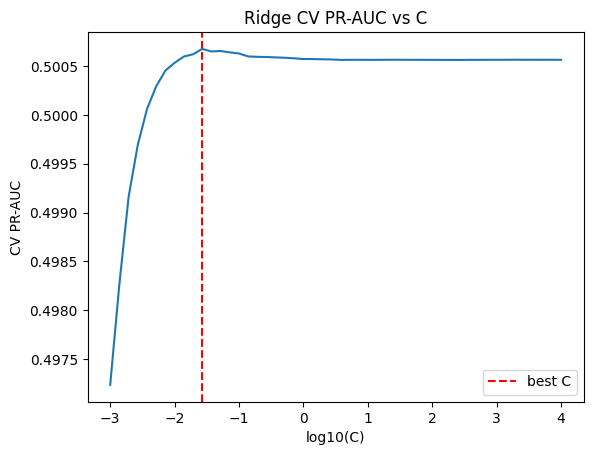

In [13]:
import matplotlib.pyplot as plt

ridge_scores = ridge_cv.scores_[1].mean(axis=0)  # shape: (n_Cs,)

plt.plot(np.log10(Cs), ridge_scores)
plt.xlabel("log10(C)")
plt.ylabel("CV PR-AUC")
plt.title("Ridge CV PR-AUC vs C")
plt.axvline(np.log10(ridge_cv.C_[0]), color="red", linestyle="--", label="best C")
plt.legend()
plt.show()

## Step 6: Predictive Performance Comparison (PR-AUC only)

We compare baseline logistic, Ridge, Lasso, and Elastic Net on the test set using only PR-AUC (average precision).

Model comparison on test set (PR-AUC only):
                  model    PR_AUC
1         Ridge (L2) CV  0.501498
0  Unpenalized Logistic  0.501463
2         Lasso (L1) CV  0.501056
3        Elastic Net CV  0.500926


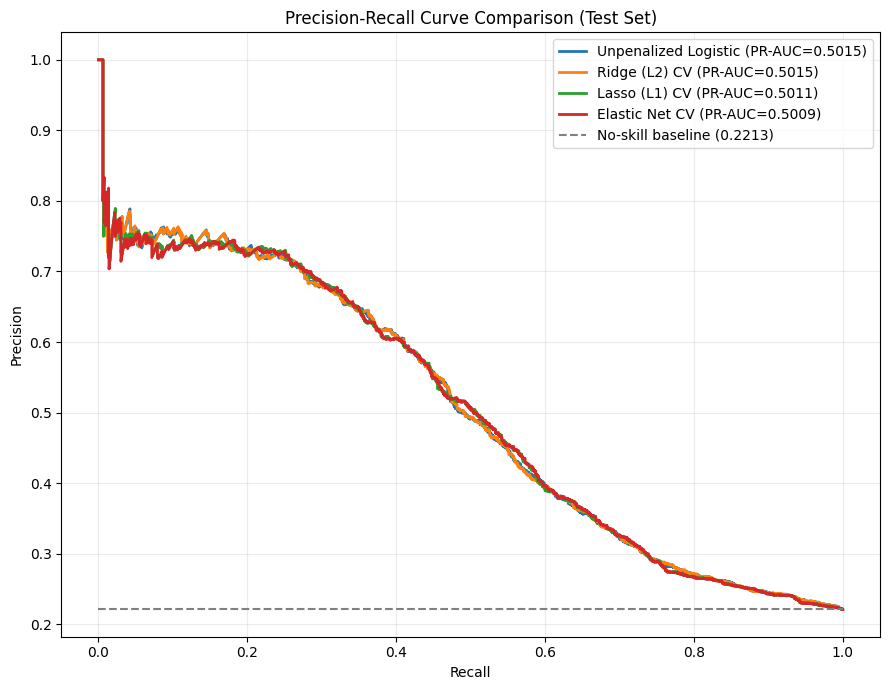

In [14]:
def eval_model_pr_auc(name, model, X_te, y_te):
    prob = model.predict_proba(X_te)[:, 1]
    return {
        "model": name,
        "PR_AUC": average_precision_score(y_te, prob),
    }, prob

baseline_row, baseline_prob = eval_model_pr_auc("Unpenalized Logistic", baseline, X_test, y_test)
ridge_row, ridge_prob = eval_model_pr_auc("Ridge (L2) CV", ridge_cv, X_test, y_test)
lasso_row, lasso_prob = eval_model_pr_auc("Lasso (L1) CV", lasso_cv, X_test, y_test)
enet_row, enet_prob = eval_model_pr_auc("Elastic Net CV", elasticnet_cv, X_test, y_test)

results = pd.DataFrame([baseline_row, ridge_row, lasso_row, enet_row]).sort_values("PR_AUC", ascending=False)

print("Model comparison on test set (PR-AUC only):")
print(results)

plt.figure(figsize=(9, 7))
for name, prob, ap in [
    ("Unpenalized Logistic", baseline_prob, baseline_row["PR_AUC"]),
    ("Ridge (L2) CV", ridge_prob, ridge_row["PR_AUC"]),
    ("Lasso (L1) CV", lasso_prob, lasso_row["PR_AUC"]),
    ("Elastic Net CV", enet_prob, enet_row["PR_AUC"]),
]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    plt.plot(recall, precision, linewidth=2, label=f"{name} (PR-AUC={ap:.4f})")

prevalence = y_test.mean()
plt.hlines(prevalence, 0, 1, colors="gray", linestyles="--", label=f"No-skill baseline ({prevalence:.4f})")
plt.title("Precision-Recall Curve Comparison (Test Set)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### James-Stein shrinkage: PAY_0 group default rates

To connect the course James-Stein story to this binary outcome, we stratify **only by PAY_0**: each level defines a group with its own default proportion. The **MLE** group rate is the within-group sample proportion. We work in **variance-stabilized** space: use $\tilde p=(k+0.5)/(n+1)$, then $z=\arcsin(\sqrt{\tilde p})$, shrink $z$ across groups, and map back with $\hat p=\sin^2(z^{\textrm{JS}})$.

Let $p$ be the number of PAY_0 groups (one coordinate per group). Pooled scale uses $\sigma^2 \approx \text{mean}_g(1/(4n_g))$. The **James-Stein** shrinkage factor and update are:

$$
B = \frac{(p-2)\,\sigma^2}{\big\lVert \hat{\mathbf{z}} - \bar{z}\,\mathbf{1} \big\rVert^2}
$$

$$
\hat{\mathbf{z}}^{\,\textrm{JS}} = \bar{z}\,\mathbf{1} + (1-B)\,\big(\hat{\mathbf{z}} - \bar{z}\,\mathbf{1}\big)
$$

Then each group's probability estimate is $\hat{p}_g = \sin^2\!\left(\hat{z}^{\,\textrm{JS}}_g\right)$.

We use `df_train` from **Step 2** (the same stratified split as scaled `X_train` / `X_test`, with no second `train_test_split`).

In [15]:
# df_train comes from Step 2 (same split as X_train; do not split again)

tbl = (
    df_train.groupby("PAY_0", observed=True)
    .agg(n=(target, "size"), k=(target, "sum"))
    .sort_index()
)
tbl["p_mle"] = tbl["k"] / tbl["n"]
k = tbl["k"].to_numpy()
n = tbl["n"].to_numpy()
p_tilde = (k + 0.5) / (n + 1)
z = np.arcsin(np.sqrt(np.clip(p_tilde, 0.0, 1.0)))
p = len(z)  # number of PAY_0 groups
zbar = z.mean()
S = np.sum((z - zbar) ** 2) + 1e-12
sigma2 = float((1.0 / (4 * n)).mean())  # pooled Var(z) scale
B = (p - 2) * sigma2 / S
B = float(np.clip(B, 0.0, 1.0))
z_shrink = zbar + (1.0 - B) * (z - zbar)
p_js = np.sin(z_shrink) ** 2

js_table = pd.DataFrame(
    {
        "PAY_0": tbl.index,
        "n": n,
        "p_mle": tbl["p_mle"].to_numpy(),
        "p_js": p_js,
    }
).set_index("PAY_0")

print(f"Number of PAY_0 groups (train), p = {p}")
print(f"James-Stein shrinkage factor B = {B:.4f} (clipped to [0, 1])")
print("\nGroup-level default rates (MLE vs JS-shrunk):")
print(js_table)

Number of PAY_0 groups (train), p = 11
James-Stein shrinkage factor B = 0.1068 (clipped to [0, 1])

Group-level default rates (MLE vs JS-shrunk):
           n     p_mle      p_js
PAY_0                           
-2      2167  0.131980  0.159699
-1      4528  0.169832  0.195722
0      11820  0.126227  0.153995
1       2949  0.341811  0.353376
2       2143  0.693420  0.668810
3        250  0.772000  0.740254
4         62  0.693548  0.666209
5         20  0.450000  0.452373
6         10  0.500000  0.494897
7          8  0.750000  0.695236
8         15  0.466667  0.466992


## Step 7: Coefficient Shrinkage Analysis

Beyond PR-AUC reporting, this section isolates how each penalty alters coefficient magnitude and sparsity across the same full feature set.

Top 12 features by average absolute coefficient:
           Baseline  Ridge_L2  Lasso_L1  Elastic_Net
PAY_0      0.578823  0.573423  0.569026     0.561221
BILL_AMT1 -0.419750 -0.325476 -0.126223    -0.123058
PAY_AMT1  -0.242424 -0.219631 -0.138544    -0.131618
PAY_AMT2  -0.166122 -0.166179 -0.084709    -0.076698
PAY_2      0.119664  0.119887  0.110280     0.111417
LIMIT_BAL -0.108850 -0.109886 -0.099842    -0.099358
BILL_AMT2  0.261877  0.155408  0.000000     0.000000
PAY_3      0.077559  0.079280  0.078393     0.077174
PAY_AMT4  -0.089384 -0.087768 -0.052591    -0.049926
EDUCATION -0.087547 -0.086713 -0.042003    -0.036214
MARRIAGE  -0.076529 -0.075829 -0.049781    -0.046494
AGE        0.068732  0.068131  0.041288     0.037804


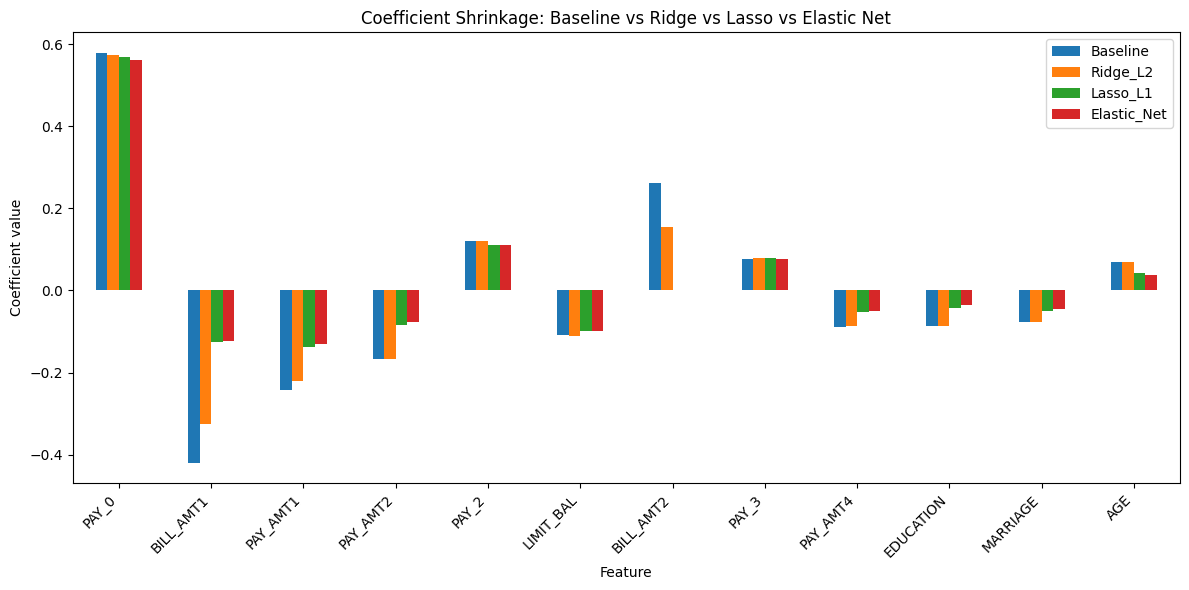

Lasso near-zero coefficients (<1e-3): 7 / 23
Ridge near-zero coefficients (<1e-3): 0 / 23
Elastic Net near-zero coefficients (<1e-3): 7 / 23
Baseline near-zero coefficients (<1e-3): 0 / 23


In [16]:
coef_compare = pd.DataFrame(
    {
        "Baseline": baseline.coef_.ravel(),
        "Ridge_L2": ridge_cv.coef_.ravel(),
        "Lasso_L1": lasso_cv.coef_.ravel(),
        "Elastic_Net": elasticnet_cv.coef_.ravel(),
    },
    index=feature_cols,
)

coef_compare["abs_mean"] = coef_compare.abs().mean(axis=1)
coef_compare = coef_compare.sort_values("abs_mean", ascending=False).drop(columns=["abs_mean"])

print("Top 12 features by average absolute coefficient:")
print(coef_compare.head(12))

top_n = 12
coef_compare.head(top_n).plot(kind="bar", figsize=(12, 6))
plt.title("Coefficient Shrinkage: Baseline vs Ridge vs Lasso vs Elastic Net")
plt.ylabel("Coefficient value")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

n_near_zero_L1 = (np.abs(coef_compare["Lasso_L1"]) < 1e-3).sum()
n_near_zero_L2 = (np.abs(coef_compare["Ridge_L2"]) < 1e-3).sum()
n_near_zero_enet = (np.abs(coef_compare["Elastic_Net"]) < 1e-3).sum()
n_near_zero_baseline = (np.abs(coef_compare["Baseline"]) < 1e-3).sum()
print(f"Lasso near-zero coefficients (<1e-3): {n_near_zero_L1} / {len(feature_cols)}")
print(f"Ridge near-zero coefficients (<1e-3): {n_near_zero_L2} / {len(feature_cols)}")
print(f"Elastic Net near-zero coefficients (<1e-3): {n_near_zero_enet} / {len(feature_cols)}")
print(f"Baseline near-zero coefficients (<1e-3): {n_near_zero_baseline} / {len(feature_cols)}")

### Bias-Variance Connection

Regularization adds bias by shrinking coefficients toward zero, but can reduce variance in estimated parameters and predictions.

- Ridge (L2) lowers variance through smooth shrinkage across all predictors.
- Lasso (L1) can further reduce variance and improve interpretability by shrinking weak coefficients toward zero.
- Elastic Net blends L1 and L2, often used when many correlated predictors exist (a middle path between full Ridge and Lasso sparsity).

If test PR-AUC remains stable or improves after shrinkage, that indicates a favorable bias-variance tradeoff: less model complexity with little or no loss in predictive utility.

## Step 8: Interpretation

Relative to the MLE baseline, Ridge typically improves stability by shrinking noisy coefficients while preserving full-model structure. Lasso adds feature-selection behavior by forcing weaker signals toward zero. Elastic Net interpolates between the two (via `l1_ratio`) and can be useful with correlated features.

The Step 6 table compares Ridge, Lasso, and Elastic Net to the unpenalized baseline using test-set PR-AUC only. Together with the bias-variance discussion, this makes the class connection explicit: regularization introduces bias to reduce variance, with the goal of maintaining or improving out-of-sample performance while controlling model complexity.

Separately, the James-Stein block uses \(B=(p-2)\sigma^2/\|\hat z-\bar z\|^2\) in arcsin-sqrt space to demonstrate group-level shrinkage mechanics for PAY_0 default rates.